# CORRELATIONS IN VLP

This file will be used to rough perform the VLP correlations and build functions for them. Given question is tubing OD of 2 7/8" nad ID of 2.441". Casing ID is 5 1/2". GOR is 1000, Ql = 20 m3/day. Pe = 120 kg/cm2 and Pwf = 100 kg/cm2

## INDEX

1. [PVT](#1)
2. [Hagedron-Brown](#2)
3. [Beggs and Brill](#3)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

<a name = "1"></a>
## PVT

In [ ]:
import numpy as np


class BlackOilPVT:
    """
    A comprehensive Black Oil PVT calculator using standard industry empirical correlations
    (Standing, Beggs-Robinson, Lee-Gonzalez-Eakin, Dranchuk-Abou-Kassem).
    Assumes standard US Oilfield Units.
    """

    def __init__(self, sg_gas=0.65, sg_oil=0.84, oil_api=None, sg_water=1.03, watercut=0.0):
        """
        Initializes the fluid with its constant surface properties.

        Args:
            sg_gas (float): Specific gravity of gas (Air = 1.0).
            sg_oil (float): Specific gravity of oil (Water = 1.0).
            oil_api (float, optional): Oil API gravity. Overrides sg_oil if provided.
            sg_water (float, optional): Specific gravity of water. Defaults to 1.03.
            watercut (float): Watercut as a decimal fraction (0.0 to 1.0).
        """
        self.sg_g = sg_gas
        self.sg_o = 141.5 / (131.5 + oil_api) if oil_api else sg_oil
        self.sg_w = sg_water
        self.wc = watercut

        # BUG FIX 1: Guard against division by zero at watercut = 1.0.
        # wor = wc / (1 - wc) blows up at full water production.
        self.wor = watercut / max(1.0 - watercut, 1e-9)

        # Calculate API gravity (used in almost all oil correlations)
        self.api = (141.5 / self.sg_o) - 131.5

    def get_pseudo_critical(self):
        """
        Calculates Sutton's pseudo-critical temperature and pressure for natural gas.

        Returns:
            tuple:
                Tpc (float): Pseudo-critical temperature in Rankine (°R).
                Ppc (float): Pseudo-critical pressure in psia.
        """
        Tpc = 187 + 330 * self.sg_g - 71.5 * self.sg_g**2
        Ppc = 667 + 15 * self.sg_g - 37.5 * self.sg_g**2
        return Tpc, Ppc

    def calculate_dak_z_factor(self, P, T, gamma_g, max_iter=100, tolerance=1e-6):
        """
        Calculates the Gas Z-factor using the Dranchuk-Abou-Kassem (DAK)
        equation of state for dry natural gas via Newton-Raphson iteration.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            gamma_g (float): Gas specific gravity.
            max_iter (int, optional): Maximum iterations for the solver. Defaults to 100.
            tolerance (float, optional): Convergence tolerance. Defaults to 1e-6.

        Returns:
            float: Gas compressibility factor (Z-factor), dimensionless.
        """
        T_r = T + 459.67
        Tpc, Ppc = self.get_pseudo_critical()
        Tpr = T_r / Tpc
        Ppr = P / Ppc

        A1, A2, A3 = 0.3265, -1.0700, -0.5339
        A4, A5, A6 = 0.01569, -0.05165, 0.5475
        A7, A8, A9 = -0.7361, 0.1844, 0.1056
        A10, A11 = 0.6134, 0.7210

        c1 = A1 + A2/Tpr + A3/(Tpr**3) + A4/(Tpr**4) + A5/(Tpr**5)
        c2 = A6 + A7/Tpr + A8/(Tpr**2)
        c3 = A9 * (A7/Tpr + A8/(Tpr**2))
        c4 = A10 / (Tpr**3)

        rho_r = 0.27 * Ppr / Tpr

        for i in range(max_iter):
            term_exp = np.exp(-A11 * (rho_r**2))

            f = (1.0 + c1*rho_r + c2*(rho_r**2) - c3*(rho_r**5) +
                 c4*(rho_r**2)*(1.0 + A11*(rho_r**2))*term_exp - (0.27 * Ppr / (rho_r * Tpr)))

            # BUG FIX 2: The analytical derivative of the DAK EOS c4 term was wrong.
            # Differentiating c4*rho^2*(1 + A11*rho^2)*exp(-A11*rho^2) w.r.t. rho gives:
            #   2*c4*rho*(1 + A11*rho^2 - A11^2*rho^4)*exp(-A11*rho^2)
            # The original code contained a spurious -A11*rho^3 term inside the bracket,
            # which caused Newton-Raphson to converge to a slightly wrong root.
            df = (c1 + 2.0*c2*rho_r - 5.0*c3*(rho_r**4) +
                  2.0*c4*rho_r*(1.0 + A11*(rho_r**2) - A11**2*(rho_r**4))*term_exp +
                  (0.27 * Ppr / ((rho_r**2) * Tpr)))

            rho_r_new = rho_r - f / df

            if abs(rho_r_new - rho_r) < tolerance:
                z_factor = 0.27 * Ppr / (rho_r_new * Tpr)
                return round(z_factor, 4)

            rho_r = rho_r_new

        raise ValueError("Z-factor solver did not converge. Check input parameters.")

    def calc_bubble_point(self, T, Rsb):
        """
        Calculates Bubble Point Pressure (Pb) using Standing's Correlation.

        Args:
            T (float): Local temperature in Fahrenheit (°F).
            Rsb (float): Solution GOR at bubble point (Initial Producing GOR) in scf/STB.

        Returns:
            float: Bubble point pressure in psia.
        """
        a = 0.00091 * T - 0.0125 * self.api
        pb = 18.2 * (((Rsb / self.sg_g) ** 0.83) * (10 ** a) - 1.4)
        return max(pb, 14.7)

    def calc_rs(self, P, T, Pb, Rsb):
        """
        Calculates Solution Gas-Oil Ratio (Rs) using Standing's Correlation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Pb (float): Bubble point pressure in psia.
            Rsb (float): Solution GOR at bubble point in scf/STB.

        Returns:
            float: Solution Gas-Oil Ratio in scf/STB.
        """
        if P >= Pb:
            return Rsb
        a = 0.00091 * T - 0.0125 * self.api
        rs = self.sg_g * (((P / 18.2) + 1.4) * (10 ** -a)) ** 1.2048
        return max(rs, 0.0)

    def calc_bo(self, P, T, Rs, Pb):
        """
        Calculates Oil Formation Volume Factor (Bo) using Standing's Correlation.
        Includes simplified Vasquez-Beggs isothermal compressibility for undersaturated conditions.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Rs (float): Solution Gas-Oil Ratio at local pressure in scf/STB.
            Pb (float): Bubble point pressure in psia.

        Returns:
            float: Oil Formation Volume Factor (Bo) in bbl/STB.
        """
        F = Rs * np.sqrt(self.sg_g / self.sg_o) + 1.25 * T
        bo_sat = 0.9759 + 0.00012 * (F ** 1.175)

        if P <= Pb:
            return bo_sat

        co = (5 * Rs + 17.2 * T - 1180 * self.sg_g + 12.61 * self.api - 1433) / (P * 10**5)
        co = max(co, 5e-6)
        bo_under = bo_sat * np.exp(-co * (P - Pb))
        return bo_under

    def calc_bg(self, P, T, Z):
        """
        Calculates Gas Formation Volume Factor (Bg) using the Real Gas Law.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Z (float): Gas compressibility factor.

        Returns:
            float: Gas Formation Volume Factor (Bg) in ft³/scf.
        """
        T_rankine = T + 460.0
        bg = 0.02827 * Z * T_rankine / P
        return bg

    def calc_bw(self, P, T):
        """
        Calculates Water Formation Volume Factor (Bw) using polynomial approximation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Water Formation Volume Factor (Bw) in bbl/STB.
        """
        delta_T = T - 60.0
        bw = 1.0 + 1.2e-4 * delta_T + 1e-6 * (delta_T ** 2) - 3.33e-6 * P
        return max(bw, 0.9)

    def calc_density_oil(self, Rs, Bo):
        """
        Calculates in-situ Oil Density.

        Args:
            Rs (float): Solution Gas-Oil Ratio at local pressure in scf/STB.
            Bo (float): Oil Formation Volume Factor at local pressure in bbl/STB.

        Returns:
            float: In-situ oil density in lbm/ft³.
        """
        rho_o_insitu = (350.0 * self.sg_o + 0.0764 * self.sg_g * Rs) / (5.615 * Bo)
        return rho_o_insitu

    def calc_density_gas(self, P, T, Z):
        """
        Calculates in-situ Gas Density using the Real Gas Law.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Z (float): Gas compressibility factor.

        Returns:
            float: In-situ gas density in lbm/ft³.
        """
        T_rankine = T + 460.0
        rho_g_insitu = 28.967 * self.sg_g * P / (Z * 10.732 * T_rankine)
        return rho_g_insitu

    def calc_viscosity_oil(self, P, T, Rs, Pb):
        """
        Calculates Oil Viscosity using Beggs-Robinson Correlation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Rs (float): Solution Gas-Oil Ratio at local pressure in scf/STB.
            Pb (float): Bubble point pressure in psia.

        Returns:
            float: Oil viscosity in centipoise (cp).
        """
        z = 3.0324 - 0.02023 * self.api
        y = 10 ** z
        x = y * (T ** -1.163)
        mu_od = 10 ** x - 1.0

        a = 10.715 * ((Rs + 100) ** -0.515)
        b = 5.44 * ((Rs + 150) ** -0.338)
        mu_os = a * (mu_od ** b)

        if P <= Pb:
            return mu_os

        m = 2.6 * (P ** 1.187) * np.exp(-11.513 - 8.98e-5 * P)
        mu_o_under = mu_os * ((P / Pb) ** m)
        return mu_o_under

    def calc_viscosity_gas(self, P, T, Z):
        """
        Calculates Gas Viscosity using the Lee-Gonzalez-Eakin correlation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Z (float): Gas compressibility factor.

        Returns:
            float: Gas viscosity in centipoise (cp).
        """
        T_rankine = T + 460.0
        Mg = 28.97 * self.sg_g
        rho_g = self.calc_density_gas(P, T, Z) / 62.4

        K = (9.379 + 0.01607 * Mg) * (T_rankine ** 1.5) / (209.2 + 19.26 * Mg + T_rankine)
        X = 3.448 + (986.4 / T_rankine) + 0.01009 * Mg
        Y = 2.447 - 0.2224 * X

        mu_g = 1e-4 * K * np.exp(X * (rho_g ** Y))
        return mu_g

    def calc_viscosity_water(self, T):
        """
        Calculates water viscosity using the Brill & Beggs correlation.

        Args:
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Water viscosity in centipoise (cp).
        """
        return np.exp(1.003 - 0.01479 * T + 0.00001982 * T**2)

    def calc_surface_tension_oil(self, P, T):
        """
        Calculates Liquid-Gas Surface Tension for oil using Baker-Swerdloff.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Oil surface tension in dynes/cm.
        """
        sigma_68 = 39.0 - 0.2571 * self.api
        sigma_100 = 37.5 - 0.2571 * self.api

        if T > 100:
            sigma_dead = sigma_100 - (T - 100) * 0.05
        else:
            sigma_dead = sigma_68 - (T - 68) * ((sigma_68 - sigma_100) / 32.0)

        sigma_dead = max(sigma_dead, 1.0)
        sigma_live = sigma_dead * np.exp(-0.0002 * P)
        return max(sigma_live, 1.0)

    def calc_surface_tension_water(self, T):
        """
        Calculates Water-Gas Surface Tension.

        Args:
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Water surface tension in dynes/cm.
        """
        sigma_w = 75.0 - 0.116 * T
        return max(sigma_w, 40.0)

    def calc_M(self, gor):
        """
        Calculates the mixture molecular weight proxy M used in the H-B friction Re number.

        Args:
            gor (float): Solution Gas-Oil Ratio at current pressure in scf/STB oil.

        Returns:
            float: M (lbm/STB liquid), dimensionless in context of Re formula.
        """
        # BUG FIX 4: GLR conversion was wrong. GLR (gas per STB *liquid*) equals
        # GOR (gas per STB *oil*) multiplied by the oil fraction (1 - wc), i.e.:
        #   glr = gor * (1 - wc) = gor / (1 + wor)
        # The original code used gor / (1 + wc), which is dimensionally incorrect
        # and over-estimates GLR at any nonzero watercut.
        glr = gor / (1.0 + self.wor)
        return (self.sg_o * 350.52 / (1 + self.wor)
                + self.sg_w * 350.52 * self.wor / (1 + self.wor)
                + self.sg_g * 0.0764 * glr)
    
    def rsb_from_test(self, Rs_test, Pwf_test, Pb, T):
        """
        Calculates bubble-point gor from test data.
        Args:
            Rs_test: GOR at test condition, scf/stb
            Pwf_test: Wellbore pressure at test condition, psia
            Pb: Bubble-point pressure, psia
            T: Test temperature, Farenheit
        Returns:
            Rsb: GOR at bubble-point, scf/stb
        """
        if Pwf_test >= Pb:
            return Rs_test          # test point already saturated -> Rs_test IS Rsb
        a = 0.00091 * T - 0.0125 * self.api
        shape_at_test = self.sg_g * (((Pwf_test / 18.2) + 1.4) * (10 ** -a)) ** 1.2048
        shape_at_pb   = self.sg_g * (((Pb / 18.2) + 1.4) * (10 ** -a)) ** 1.2048
        return Rs_test * (shape_at_pb / shape_at_test)

    def fluid_properties_dict(self, P, T, Rsb, Pb=0):
        """
        Calculates all fluid properties at a specific pressure and temperature node.
        Correctly blends oil and water properties based on in-situ volume fractions.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Rsb (float): Initial producing Gas-Oil Ratio in scf/STB.
            Pb (float): Bubble-point pressure in psia. Calculated if 0.

        Returns:
            dict: A dictionary containing all blended liquid and gas properties required
                  by multiphase flow correlations like Hagedorn-Brown.
        """
        Pb = self.calc_bubble_point(T, Rsb) if Pb == 0 else Pb

        Rs = self.calc_rs(P, T, Pb, Rsb)
        Z = self.calculate_dak_z_factor(P, T, self.sg_g)
        M = self.calc_M(Rs)

        Bo = self.calc_bo(P, T, Rs, Pb)
        Bw = self.calc_bw(P, T)
        Bg = self.calc_bg(P, T, Z)

        # Surface volume fractions (used for viscosity and surface tension blending,
        # consistent with H-B correlation literature)
        fo = 1.0 / (1.0 + self.wor)
        fw = self.wor / (1.0 + self.wor)

        # In-situ volume fractions (used for density blending)
        # These account for the reservoir FVF of each phase.
        total_res_vol = Bo + self.wor * Bw
        fo_insitu = Bo / total_res_vol
        fw_insitu = (self.wor * Bw) / total_res_vol

        # Pure phase properties
        rho_o = self.calc_density_oil(Rs, Bo)
        rho_w = 62.4 * self.sg_w / Bw
        mu_o = self.calc_viscosity_oil(P, T, Rs, Pb)
        mu_w = self.calc_viscosity_water(T)
        sigma_o = self.calc_surface_tension_oil(P, T)
        sigma_w = self.calc_surface_tension_water(T)

        rho_l = rho_o * fo_insitu + rho_w * fw_insitu

        # Viscosity and surface tension: blended with surface fractions per H-B convention
        mu_l = mu_o * fo + mu_w * fw
        sigma_l = sigma_o * fo + sigma_w * fw

        return {
            "M": M,
            "Pb": Pb,
            "Rsb": Rsb,
            "gor": Rs,
            "glr": Rsb / (1.0 + self.wor),
            "rho_l": rho_l,
            "rho_g": self.calc_density_gas(P, T, Z),
            "mu_l": mu_l,
            "mu_g": self.calc_viscosity_gas(P, T, Z),
            "sigma_l": sigma_l,
            "Bo": Bo,
            "Bg": Bg,   # ft³/scf
            "Bw": Bw,
            "Pr": P,
            "Tr": T,
            "Z": Z,
        }

<a name = "2"></a>
## HAGEDRON-BROWN


In [15]:
import numpy as np
import matplotlib.pyplot as plt


class HagedornBrown:
    """
    Calculates multiphase flow pressure gradients and VLP curves for vertical wellbores
    using the Hagedorn-Brown correlation and a coupled Black Oil PVT model.
    Includes Griffith-Wallis bubble flow detection and holdup correction.
    """

    def __init__(self, tubing_id, tubing_od, casing_id, roughness, pvt_model,
                 fluid_properties, watercut=0.0, theta=0.0):
        self.tid      = tubing_id #ft
        self.tod      = tubing_od #ft
        self.cid      = casing_id #ft
        self.roughness = roughness #ft
        self.pvt_model = pvt_model 
        self.wc       = watercut #ratio
        self.wor      = watercut / (1.0 - watercut + 1e-9)
        self.theta    = np.radians(theta) #degrees
        self.Ap       = (np.pi / 4.0) * self.tid**2
        self.Pb       = pvt_model.calc_bubble_point
        self.fp       = fluid_properties #{"M","Pb","Rsb","gor","glr","rho_l","rho_g","mu_l","mu_g","sigma_l","Bo","Bg","Bw","Pr","Tr","Z",}

    # ------------------------------------------------------------------
    # Fluid property update
    # ------------------------------------------------------------------

    def update_fluid_properties(self, P, T, Ql):
        self.Ql = Ql
        self.fp = self.pvt_model.fluid_properties_dict(
            P, T, self.fp["Rsb"], self.fp["Pb"]
        )

    # ------------------------------------------------------------------
    # Hagedorn-Brown dimensionless groups
    # ------------------------------------------------------------------

    def dimensionless_numbers(self):
        """
        Calculates the required Hagedorn-Brown dimensionless groups and
        sets Vsl, Vsg, Vm in self.fp.

        Returns:
            tuple: Nl, CNl, Nlv, Ngv, Nd (all dimensionless).
        """
        fo = 1.0 / (1.0 + self.wor)
        fw = self.wor  / (1.0 + self.wor)

        # In-situ liquid volumetric rate  [ft³/day]
        q_liquid_insitu = 5.615 * self.Ql * (self.fp["Bo"] * fo + self.fp["Bw"] * fw)
        self.fp["Vsl"]  = q_liquid_insitu / (86400.0 * self.Ap)

        # ----------------------------------------------------------------
        # BUG FIX — free gas calculation
        # ----------------------------------------------------------------
        # fp["glr"] must be the TOTAL surface producing GLR (scf / STB liquid),
        # derived from Rsb (initial GOR), NOT from Rs (dissolved GOR at local P).
        #
        # The PVT dict previously stored glr = Rs/(1+wor), which equals gor*fo
        # at every pressure, making free_gas_scf = Ql*(glr - gor*fo) = 0 always.
        # With Vsg = 0 there is no gas phase: holdup = 1, mixture density =
        # liquid density at every rate, and the only gradient that changes with
        # rate is friction (∝ Vm²). That produces the monotonically-increasing
        # Pwf curve seen in the plot — the U-shape requires gas gravity relief
        # to dominate at low rates, which only appears when free gas is non-zero.
        #
        # Fix applied in BlackOilPVT.fluid_properties_dict:
        #   "glr": Rsb / (1 + wor)   ← total surface GLR, constant with P
        #   "gor": Rs                 ← dissolved portion, decreases below Pb
        # Now below bubble point:  glr > gor*fo  =>  free_gas_scf > 0  ✓
        # ----------------------------------------------------------------
        free_gas_scf   = max(0.0, self.Ql * (self.fp["glr"] - self.fp["gor"] * fo))
        q_gas_insitu   = (free_gas_scf
                          * (14.7 / self.fp["Pr"])
                          * ((self.fp["Tr"] + 460.0) / 520.0)
                          * self.fp["Z"])
        self.fp["Vsg"] = q_gas_insitu / (86400.0 * self.Ap)
        self.fp["Vm"]  = self.fp["Vsl"] + self.fp["Vsg"]

        # H-B dimensionless groups
        base_term = 1.0 / (self.fp["rho_l"] * self.fp["sigma_l"] ** 3)
        Nl  = 0.15726 * self.fp["mu_l"] * (base_term ** 0.25)
        CNl = 0.061 * Nl**3 - 0.0929 * Nl**2 + 0.0505 * Nl + 0.0019

        Nlv = 1.938 * self.fp["Vsl"] * (self.fp["rho_l"] / self.fp["sigma_l"]) ** 0.25
        Ngv = 1.938 * self.fp["Vsg"] * (self.fp["rho_l"] / self.fp["sigma_l"]) ** 0.25
        Nd  = 120.872 * self.tid     * (self.fp["rho_l"] / self.fp["sigma_l"]) ** 0.5

        return Nl, CNl, Nlv, Ngv, Nd

    # ------------------------------------------------------------------
    # Bubble-flow regime detection  (Griffith & Wallis, 1961)
    # ------------------------------------------------------------------

    def is_bubble_flow(self):
        """
        Determines whether the current flow conditions fall in the bubble-flow
        regime using the Griffith-Wallis criterion.

        Bubble flow exists when the in-situ gas void fraction (λg = Vsg/Vm)
        is less than the boundary value LB:
            LB = max(0.25,  1.071 − 0.2218 · Vm² / d)

        Velocities must be computed by dimensionless_numbers() before calling
        this method (they are stored in self.fp).

        Returns:
            bool: True if bubble flow, False otherwise.
        """
        Vm  = self.fp.get("Vm",  0.0)
        Vsg = self.fp.get("Vsg", 0.0)

        if Vm <= 1e-9:
            return False

        # Griffith-Wallis bubble-flow boundary
        LB = 1.071 - 0.2218 * (Vm ** 2) / self.tid
        LB = max(LB, 0.25)

        lambda_g = Vsg / Vm          # in-situ gas void fraction (no-slip)
        return lambda_g < LB

    # ------------------------------------------------------------------
    # Griffith holdup for bubble flow
    # ------------------------------------------------------------------

    def griffith_holdup(self):
        """
        Calculates liquid holdup for bubble-flow regime using the
        Griffith-Wallis correlation and updates mixture properties in self.fp.

        The bubble-rise velocity Vs = 0.8 ft/s is a standard field-unit
        constant for oil–gas systems.

        Quadratic form (Griffith & Wallis):
            Vs·Hl² − (Vm + Vs)·Hl + Vsl = 0
        Solved directly:
            Hl = 1 − ½·[1 + Vm/Vs − √((1 + Vm/Vs)² − 4·Vsg/Vs)]

        Returns:
            float: Liquid holdup (0.0 – 1.0).
        """
        Vm  = self.fp["Vm"]
        Vsg = self.fp["Vsg"]
        Vs  = 0.8   # bubble rise velocity, ft/s

        discriminant = (1.0 + Vm / Vs) ** 2 - 4.0 * Vsg / Vs
        # Discriminant is always ≥ 0 inside bubble-flow region (λg < LB ≤ 0.25)
        discriminant = max(discriminant, 0.0)

        Hl = 1.0 - 0.5 * (1.0 + Vm / Vs - np.sqrt(discriminant))
        Hl = max(0.0, min(Hl, 1.0))

        self.fp["rho_m"] = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1.0 - Hl)
        self.fp["mu_m"]  = (self.fp["mu_l"] ** Hl) * (self.fp["mu_g"] ** (1.0 - Hl))

        return Hl

    # ------------------------------------------------------------------
    # Hagedorn-Brown holdup (slug / transition / mist)
    # ------------------------------------------------------------------

    def liquid_holdup(self):
        """
        Calculates liquid holdup using the Hagedorn-Brown correlation.
        Also sets rho_m and mu_m in self.fp.

        Returns:
            float: Liquid holdup (0.0 – 1.0).
        """
        Nl, CNl, Nlv, Ngv, Nd = self.dimensionless_numbers()
        Ngv_safe = max(Ngv, 1e-6)

        H = ((Nlv / (Ngv_safe ** 0.575))
             * (self.fp["Pr"] / 14.7) ** 0.1
             * (CNl / Nd))

        Hl_psi = np.sqrt(
            (0.0047 + 1123.32 * H + 729489.64 * H ** 2)
            / (1.0 + 1097.1566 * H + 722153.97 * H ** 2)
        )

        B = Ngv * (Nlv ** 0.38) / (Nd ** 2.14)
        if B <= 0.025:
            psi = 27170 * B**3 - 317.52 * B**2 + 0.5472 * B + 0.9999
        elif B <= 0.055:
            psi = -533.33 * B**2 + 58.524 * B + 0.1171
        else:
            psi = 2.5714 * B + 1.5962

        Hl = max(0.0, min(Hl_psi * psi, 1.0))

        self.fp["rho_m"] = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1.0 - Hl)
        self.fp["mu_m"]  = (self.fp["mu_l"] ** Hl) * (self.fp["mu_g"] ** (1.0 - Hl))

        return Hl

    # ------------------------------------------------------------------
    # Combined holdup dispatcher
    # ------------------------------------------------------------------

    def get_holdup(self):
        """
        Routes to the correct holdup correlation based on flow regime.

        Calls dimensionless_numbers() first so that Vm / Vsg are current,
        then checks for bubble flow. Returns Hl from whichever method applies.

        Returns:
            float: Liquid holdup (0.0 – 1.0).
        """
        # dimensionless_numbers() populates Vsl, Vsg, Vm — required by is_bubble_flow()
        # liquid_holdup() calls dimensionless_numbers() again internally, but
        # self.fp velocities are already set so the second call is consistent.
        self.dimensionless_numbers()

        if self.is_bubble_flow():
            return self.griffith_holdup()
        else:
            return self.liquid_holdup()

    # ------------------------------------------------------------------
    # Friction factor  (Jain / Colebrook approximation)
    # ------------------------------------------------------------------

    def frictional_factor(self, Hl):
        """
        Calculates the two-phase Darcy friction factor.

        Args:
            Hl (float): Liquid holdup already computed for this step.

        Returns:
            float: Darcy friction factor (dimensionless).
        """
        # BUG FIX — double holdup call removed.
        # The original frictional_factor() called self.liquid_holdup() internally,
        # so calculate_gradient() triggered two full holdup computations per step:
        # one from the explicit self.liquid_holdup() call and one hidden inside here.
        # Hl is now passed in from calculate_gradient() to keep a single code path.
        lambda_l = self.fp["Vsl"] / max(self.fp["Vm"], 1e-6)
        self.fp["rho_ns"] = (self.fp["rho_l"] * lambda_l
                             + self.fp["rho_g"] * (1.0 - lambda_l))

        Re = (2.2e-2 * self.Ql * self.fp["M"]
              / (self.tid
                 * self.fp["mu_l"] ** Hl
                 * self.fp["mu_g"] ** (1.0 - Hl)))

        if Re < 2000:
            return 64.0 / max(Re, 1.0)
        else:
            return (1.14 - 2.0 * np.log10(
                self.roughness + 21.25 / (Re ** 0.9)
            )) ** -2

    # ------------------------------------------------------------------
    # Pressure gradient
    # ------------------------------------------------------------------

    def calculate_gradient(self):
        """
        Calculates the total multiphase pressure gradient (psi/ft).

        Routes holdup through get_holdup() which selects Griffith (bubble)
        or Hagedorn-Brown (slug/mist) automatically.

        Returns:
            float: Total pressure gradient in psi/ft.
        """
        Hl = self.get_holdup()
        f  = self.frictional_factor(Hl)

        dp_dh_el   = self.fp["rho_m"] * np.cos(self.theta) / 144.0
        gc         = 32.174
        dp_dh_fric = (f * self.fp["rho_ns"] * self.fp["Vm"] ** 2) / (2.0 * gc * self.tid * 144.0)

        return dp_dh_el + dp_dh_fric

    # ------------------------------------------------------------------
    # Pressure traverse
    # ------------------------------------------------------------------

    def calculate_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                                    total_depth, step_size, Ql):
        """
        Calculates the wellbore pressure profile via Euler integration.

        Returns:
            tuple: (depths [ft], pressures [psia])
        """
        depths        = [0.0]
        pressures     = [Pth]
        current_P     = Pth
        current_depth = 0.0
        temp_gradient = (bottomhole_temp - surface_temp) / total_depth

        while current_depth < total_depth:
            next_depth   = min(current_depth + step_size, total_depth)
            actual_step  = next_depth - current_depth
            current_temp = surface_temp + temp_gradient * current_depth

            self.update_fluid_properties(current_P, current_temp, Ql)
            dp_dz     = self.calculate_gradient()
            current_P += dp_dz * actual_step
            current_depth = next_depth

            depths.append(current_depth)
            pressures.append(current_P)

        return depths, pressures

    # ------------------------------------------------------------------
    # Plotting helpers
    # ------------------------------------------------------------------

    def plot_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                               total_depth, step_size, Ql):
        depths, pressures = self.calculate_pressure_traverse(
            Pth, surface_temp, bottomhole_temp, total_depth, step_size, Ql
        )
        plt.plot(pressures, depths, color='blue', linewidth=2)
        plt.gca().invert_yaxis()
        plt.xlabel('Pressure (psia)')
        plt.ylabel('Depth (ft)')
        plt.title('Pressure Traverse Curve')
        plt.grid(True)
        plt.show()
        return pressures[-1]

    def plot_vlp_curve(self, Pth, surface_temp, bottomhole_temp,
                       depth, Qmin, Qmax, step_size):
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, Qmax - Qmin)

        for q in rates:
            _, pressures = self.calculate_pressure_traverse(
                Pth, surface_temp, bottomhole_temp, depth, step_size, q
            )
            Pwf_points.append(pressures[-1])

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        plt.title('VLP Curve')
        plt.grid(True)
        plt.show()

    def vlp_curve_plot_linear(self, Pth, depth, Qmin, Qmax, step_size):
        """Simplified single-gradient VLP (stale PVT — approximate only)."""
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, int((Qmax - Qmin) / step_size))

        for q in rates:
            self.Ql = q
            Pwf = Pth + self.calculate_gradient() * depth
            Pwf_points.append(Pwf)

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')

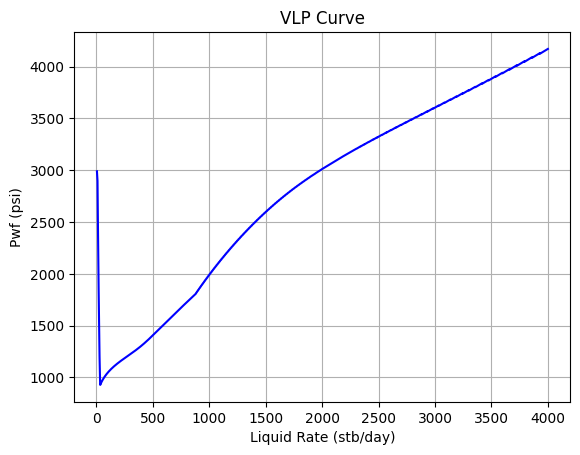

In [16]:
pvt_data = BlackOilPVT(sg_gas=0.65, sg_oil=141.5/(131.5+35), sg_water=1.07, watercut =0.33 )
Rsb = pvt_data.rsb_from_test(480, 346.6, 1800, 80)
fp = pvt_data.fluid_properties_dict(346.6, 80, Rsb, 1800)

hg = HagedornBrown(2.441/12, 2.875/12, 5.5/12, 0.0006/12, pvt_data, fp)
hg.plot_vlp_curve(346.6, 80, 130, 8245, 5, 4000, 50)

<a name = '3'></a>
## Beggs and Brill

In [ ]:
class Beggs_Brill:
    def __init__(self, tubing_id, tubing_od, casing_id, roughness, pvt_model,
                 fluid_properties, watercut=0.0, theta=0.0):
        self.tid      = tubing_id #ft
        self.tod      = tubing_od #ft
        self.cid      = casing_id #ft
        self.roughness = roughness #ft
        self.pvt_model = pvt_model 
        self.wc       = watercut #ratio
        self.wor      = watercut / (1.0 - watercut + 1e-9)
        self.theta    = np.radians(theta) #degrees
        self.Ap       = (np.pi / 4.0) * self.tid**2
        self.fp       = fluid_properties #{"M","Pb","Rsb","gor","glr","rho_l","rho_g","mu_l","mu_g","sigma_l","Bo","Bg","Bw","Pr","Tr","Z",}
        self._superficial_velocities()

    def _update_fluid_properties(self, P, T, Ql):
        self.Ql = Ql
        self.fp = self.pvt_model.fluid_properties_dict(
            P, T, self.fp["Rsb"], self.fp["Pb"]
        )
    
    def _superficial_velocities(self):
        fo = (1 - self.wc)
        fw = self.wc

        q_liquid_insitu = 5.615 * self.Ql * (self.fp["Bo"] * fo + self.fp["Bw"] * fw)
        self.fp["Vsl"]  = q_liquid_insitu / (86400.0 * self.Ap)

        free_gas_scf   = max(0.0, self.Ql * (self.fp["glr"] - self.fp["gor"] * fo))
        q_gas_insitu   = (free_gas_scf
                          * (14.7 / self.fp["Pr"])
                          * ((self.fp["Tr"] + 460.0) / 520.0)
                          * self.fp["Z"])
        self.fp["Vsg"] = q_gas_insitu / (86400.0 * self.Ap)
        self.fp["Vm"]  = self.fp["Vsl"] + self.fp["Vsg"]

        self.fp["Cl"] = self.fp["Vsl"] / self.fp["Vm"]

    def _dimensionless_numbers(self):
        self._superficial_velocities()
        Gm = self.fp["rho_l"] * self.fp["Vsl"] + self.fp["rho_g"] * self.fp["Vsg"]

        L1 = 316 * self.fp["Cl"] ** 0.302
        L2 = 0.0009252 * self.fp["Cl"] ** (-2.4684)
        L3 = 0.1 * self.fp["Cl"] ** (-1.4516)
        L4 = 0.5 * self.fp["Cl"] ** (-6.738)

        Nfr = self.fp["Vm"]**2/(32.17 * self.tid)

        return Gm, L1, L2, L3, L4, Nfr
    
    def find_flow_pattern(self, Gm, L1, L2, L3, L4, Nfr):
        if (self.fp["Cl"]<0.01 and Nfr < L1) or (self.fp["Cl"] >= 0.01 and Nfr < L2):
            return "segregated"
        elif (self.fp["Cl"]>=0.01 and L2 <= Nfr <= L3):
            return "transitional"
        elif (0.01 <= self.fp["Cl"] < 0.4 and L3 < Nfr <= L1) or (self.fp["Cl"] >= 0.4 and L3 < Nfr <= L4):
            return "intermittent"
        elif (self.fp["Cl"]<0.4 and Nfr >= L1) or (self.fp["Cl"] >= 0.4 and Nfr > L4):
            return "distributed"
        
    def calculate_holdup(self, Gm, L1, L2, L3, L4, Nfr):
        Nlv = 1.938 * self.fp["Vsl"] * (self.fp["rho_l"]/self.fp["sigma_l"])**0.25
        flow_pattern = self.find_flow_pattern(Gm, L1, L2, L3, L4, Nfr)
        
        if flow_pattern == "segregated":
            Hl0 = 0.98 * (self.fp["Cl"]**0.4846/Nfr**0.0868)
            C = (1 - self.fp["Cl"]) * np.log(0.011 * Nlv ** 3.359 * self.fp["Cl"] ** (-3.768) * Nfr**(-1.614))
        elif flow_pattern == "intermittent":
            Hl0 = 0.845 * (self.fp["Cl"]**0.5351/Nfr**0.0173)
            C = (1 - self.fp["Cl"]) * np.log(2.96 * Nlv ** (-0.4473) * self.fp["Cl"] ** 0.305 * Nfr**(0.0978))
        elif flow_pattern == "distributed":
            Hl0 = 1.065 * (self.fp["Cl"]**0.5824/Nfr**0.0609)
            C = 0
        elif flow_pattern == "transitional":
            Hl0 = 0.98 * (self.fp["Cl"]**0.4846/Nfr**0.0868)
            C = (1 - self.fp["Cl"]) * np.log(0.011 * Nlv ** 3.359 * self.fp["Cl"] ** (-3.768) * Nfr**(-1.614))
            psi = 1 + C * (np.sin(1.8 * self.theta) - 0.333 * np.sin(1.8* self.theta)**3)
            Hl_segregated = Hl0 * psi
            Hl0 = 0.845 * (self.fp["Cl"]**0.5351/Nfr**0.0173)
            C = (1 - self.fp["Cl"]) * np.log(2.96 * Nlv ** (-0.4473) * self.fp["Cl"] ** 0.305 * Nfr**(0.0978))
            psi = 1 + C * (np.sin(1.8 * self.theta) - 0.333 * np.sin(1.8* self.theta)**3)
            Hl_intermittent = Hl0*psi

            A = (L3 - Nfr)/(L3 - L2)
            Hl = A * Hl_segregated + (1-A) * Hl_intermittent
            return max(Hl, self.fp["Cl"])
        
        psi = 1 + C * (np.sin(1.8 * self.theta) - 0.333 * np.sin(1.8* self.theta)**3)
        Hl = Hl0 * psi
        return max(Hl, self.fp["Cl"])
    
    def frictional_factor(self, Gm, L1, L2, L3, L4, Nfr):
        rho_ns = self.fp["rho_l"] * self.fp["Cl"] + self.fp["rho_g"] * (1 - self.fp["Cl"])
        mu_ns = self.fp["mu_l"] * self.fp["Cl"] + self.fp["mu_g"] * (1 - self.fp["Cl"])
        Re = 1488 * rho_ns * self.fp["Vm"] *self.tid / mu_ns

        if Re < 2000:
            f = 64.0 / max(Re, 1.0)
        else:
            f = (1.14 - 2.0 * np.log10(self.roughness + 21.25 / (Re ** 0.9))) ** -2
        
        H_L = max(self.calculate_holdup(Gm, L1, L2, L3, L4, Nfr), 1e-6) # Actual slip holdup calculated previously
        y = max(self.fp["Cl"] / (H_L ** 2), 1e-6)
        ln_y = np.log(y)
        
        if 1.0 <= y <= 1.2:
            S = np.log(2.2 * y - 1.2)
        else:
            denominator = -0.0523 + 3.182 * ln_y - 0.8725 * (ln_y ** 2) + 0.01853 * (ln_y ** 4)
            S = ln_y / denominator
            
        f_prime = f * np.exp(S)
        if self.fp["Cl"] <0.001:
            f_prime = f
        
        return f_prime, H_L
    
    def calculate_gradient(self, P):
        Gm, L1, L2, L3, L4, Nfr = self._dimensionless_numbers()
        f_prime, Hl = self.frictional_factor(Gm, L1, L2, L3, L4, Nfr)
        rho_m = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1-Hl)
        dp_dz = 1/144 * ( np.sin(self.theta)*rho_m + f_prime * Gm * self.fp["Vm"]/(2*32.17*self.tid) )/( 1 - rho_m * self.fp["Vm"] * self.fp["Vsg"] / (32.17 * P/144))
        return dp_dz
    
    def calculate_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                                    total_depth, step_size, Ql):
        """
        Calculates the wellbore pressure profile via Euler integration.

        Returns:
            tuple: (depths [ft], pressures [psia])
        """
        depths        = [0.0]
        pressures     = [Pth]
        current_P     = Pth
        current_depth = 0.0
        temp_gradient = (bottomhole_temp - surface_temp) / total_depth

        while current_depth < total_depth:
            next_depth   = min(current_depth + step_size, total_depth)
            actual_step  = next_depth - current_depth
            current_temp = surface_temp + temp_gradient * current_depth

            self.update_fluid_properties(current_P, current_temp, Ql)
            dp_dz     = self.calculate_gradient(current_P)
            current_P += dp_dz * actual_step
            current_depth = next_depth

            depths.append(current_depth)
            pressures.append(current_P)

        return depths, pressures

    def plot_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                               total_depth, step_size, Ql):
        depths, pressures = self.calculate_pressure_traverse(
            Pth, surface_temp, bottomhole_temp, total_depth, step_size, Ql
        )
        plt.plot(pressures, depths, color='blue', linewidth=2)
        plt.gca().invert_yaxis()
        plt.xlabel('Pressure (psia)')
        plt.ylabel('Depth (ft)')
        plt.title('Pressure Traverse Curve')
        plt.grid(True)
        plt.show()
        return pressures[-1]

    def plot_vlp_curve(self, Pth, surface_temp, bottomhole_temp,
                       depth, Qmin, Qmax, step_size):
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, Qmax - Qmin)

        for q in rates:
            _, pressures = self.calculate_pressure_traverse(
                Pth, surface_temp, bottomhole_temp, depth, step_size, q
            )
            Pwf_points.append(pressures[-1])

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        plt.title('VLP Curve')
        plt.grid(True)
        plt.show()

    def vlp_curve_plot_linear(self, Pth, depth, Qmin, Qmax, step_size):
        """Simplified single-gradient VLP (stale PVT — approximate only)."""
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, int((Qmax - Qmin) / step_size))

        for q in rates:
            self.Ql = q
            Pwf = Pth + self.calculate_gradient() * depth
            Pwf_points.append(Pwf)

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        

In [6]:
import numpy as np
import matplotlib.pyplot as plt

class Beggs_Brill:
    """
    Calculates multiphase flow pressure gradients and VLP curves for wellbores
    at any inclination angle using the Beggs and Brill (1973) correlation.
    """
    def __init__(self, tubing_id, tubing_od, casing_id, roughness, pvt_model,
                 fluid_properties, watercut=0.0, theta=0.0):
        """
        Initializes the wellbore geometry and base PVT parameters.

        Args:
            tubing_id (float): Tubing inner diameter in feet (ft).
            tubing_od (float): Tubing outer diameter in feet (ft).
            casing_id (float): Casing inner diameter in feet (ft).
            roughness (float): Absolute pipe roughness in feet (ft).
            pvt_model (object): Instance of the BlackOilPVT class.
            fluid_properties (dict): Initial dictionary of PVT properties.
            watercut (float): Watercut as a decimal fraction (0.0 to 1.0).
            theta (float): Well deviation from vertical in degrees (0 = vertical).
        """
        self.tid = tubing_id
        self.tod = tubing_od
        self.cid = casing_id
        self.roughness = roughness
        self.pvt_model = pvt_model 
        self.wc = watercut
        
        # Convert deviation from vertical (UI) to radians
        self.theta = np.radians(theta) 
        
        self.Ap = (np.pi / 4.0) * self.tid**2
        self.fp = fluid_properties 
        self.Ql = 0.0

    def _update_fluid_properties(self, P, T, Ql):
        """
        Updates the in-situ fluid properties and superficial velocities 
        based on local pressure and temperature.
        """
        self.Ql = Ql
        self.fp = self.pvt_model.fluid_properties_dict(
            P, T, self.fp["Rsb"], self.wc
        )
        self._superficial_velocities()
    
    def _superficial_velocities(self):
        """Calculates in-situ superficial velocities and no-slip liquid holdup (Cl)."""
        fo = (1.0 - self.wc)
        fw = self.wc

        q_liquid_insitu = 5.615 * self.Ql * (self.fp["Bo"] * fo + self.fp["Bw"] * fw)
        self.fp["Vsl"] = q_liquid_insitu / (86400.0 * self.Ap)

        free_gas_scf = max(0.0, self.Ql * (self.fp["glr"] - self.fp["gor"] * fo))
        q_gas_insitu = (free_gas_scf * (14.7 / self.fp["Pr"]) 
                        * ((self.fp["Tr"] + 460.0) / 520.0) * self.fp["Z"])
        
        self.fp["Vsg"] = q_gas_insitu / (86400.0 * self.Ap)
        self.fp["Vm"]  = self.fp["Vsl"] + self.fp["Vsg"]
        
        # No-slip liquid holdup
        self.fp["Cl"] = self.fp["Vsl"] / max(self.fp["Vm"], 1e-6)

    def _dimensionless_numbers(self):
        """Calculates Beggs and Brill specific dimensionless groups."""
        self._superficial_velocities()
        Gm = self.fp["rho_l"] * self.fp["Vsl"] + self.fp["rho_g"] * self.fp["Vsg"]
        
        Cl = max(self.fp["Cl"], 1e-6) # Prevent divide-by-zero
        L1 = 316.0 * Cl ** 0.302
        L2 = 0.0009252 * Cl ** (-2.4684)
        L3 = 0.1 * Cl ** (-1.4516)
        L4 = 0.5 * Cl ** (-6.738)

        # Froude Number
        Nfr = (self.fp["Vm"]**2) / (32.174 * self.tid)

        return Gm, L1, L2, L3, L4, Nfr
    
    def find_flow_pattern(self, L1, L2, L3, L4, Nfr):
        """Determines the Beggs and Brill flow pattern (Segregated, Intermittent, Distributed, Transitional)."""
        Cl = self.fp["Cl"]
        if (Cl < 0.01 and Nfr < L1) or (Cl >= 0.01 and Nfr < L2):
            return "segregated"
        elif (Cl >= 0.01 and L2 <= Nfr <= L3):
            return "transitional"
        elif (0.01 <= Cl < 0.4 and L3 < Nfr <= L1) or (Cl >= 0.4 and L3 < Nfr <= L4):
            return "intermittent"
        elif (Cl < 0.4 and Nfr >= L1) or (Cl >= 0.4 and Nfr > L4):
            return "distributed"
        return "distributed" # Fallback
        
    def calculate_holdup(self, L1, L2, L3, L4, Nfr):
        """
        Calculates the actual liquid holdup fraction (Hl), including angle 
        correction (psi) and transitional blending.
        """
        Cl = max(self.fp["Cl"], 1e-6)
        Nlv = 1.938 * self.fp["Vsl"] * (self.fp["rho_l"] / max(self.fp["sigma_l"], 1e-6))**0.25
        flow_pattern = self.find_flow_pattern(L1, L2, L3, L4, Nfr)
        
        # B&B uses angle from HORIZONTAL (0 = horizontal, 90 = vertical)
        theta_h = (np.pi / 2.0) - self.theta 
        sin_term = np.sin(1.8 * theta_h)

        def get_C_and_Hl0(pattern):
            if pattern == "segregated":
                hl0 = 0.98 * (Cl**0.4846 / Nfr**0.0868)
                c = (1 - Cl) * np.log(0.011 * Nlv**3.539 * Cl**(-3.768) * Nfr**(-1.614))
            elif pattern == "intermittent":
                hl0 = 0.845 * (Cl**0.5351 / Nfr**0.0173)
                c = (1 - Cl) * np.log(2.96 * Nlv**(-0.4473) * Cl**0.305 * Nfr**(0.0978))
            else: # distributed
                hl0 = 1.065 * (Cl**0.5824 / Nfr**0.0609)
                c = 0.0
                
            # PDF Constraints: Hl(0) >= Cl and C >= 0
            return max(hl0, Cl), max(c, 0.0)

        # Apply interpolation if falling between segregated and intermittent
        if flow_pattern == "transitional":
            hl0_seg, c_seg = get_C_and_Hl0("segregated")
            psi_seg = 1.0 + c_seg * (sin_term - 0.333 * sin_term**3)
            hl_seg = hl0_seg * psi_seg

            hl0_int, c_int = get_C_and_Hl0("intermittent")
            psi_int = 1.0 + c_int * (sin_term - 0.333 * sin_term**3)
            hl_int = hl0_int * psi_int

            A = (L3 - Nfr) / (L3 - L2)
            Hl = A * hl_seg + (1.0 - A) * hl_int
        else:
            hl0, c = get_C_and_Hl0(flow_pattern)
            psi = 1.0 + c * (sin_term - 0.333 * sin_term**3)
            Hl = hl0 * psi

        # PDF Final Modifications: Hl must be between Cl and 1.0
        return max(Cl, min(Hl, 1.0))
    
    def frictional_factor(self, Gm, L1, L2, L3, L4, Nfr):
        """Calculates the corrected two-phase friction factor and returns the actual Holdup."""
        Cl = self.fp["Cl"]
        rho_ns = self.fp["rho_l"] * Cl + self.fp["rho_g"] * (1 - Cl)
        mu_ns = self.fp["mu_l"] * Cl + self.fp["mu_g"] * (1 - Cl)
        
        Re = 1488.0 * rho_ns * self.fp["Vm"] * self.tid / max(mu_ns, 1e-6)

        if Re < 2000:
            f = 64.0 / max(Re, 1.0)
        else:
            f = (1.14 - 2.0 * np.log10(self.roughness + 21.25 / (Re ** 0.9))) ** -2
        
        H_L = max(self.calculate_holdup(L1, L2, L3, L4, Nfr), 1e-6) 
        y = max(Cl / (H_L ** 2), 1e-6)
        ln_y = np.log(y)
        
        if 1.0 <= y <= 1.2:
            S = np.log(2.2 * y - 1.2)
        else:
            denominator = -0.0523 + 3.182 * ln_y - 0.8725 * (ln_y ** 2) + 0.01853 * (ln_y ** 4)
            S = ln_y / denominator
            
        f_prime = f * np.exp(S)
        
        # PDF Modification: Force approach gas at low liquid content
        if Cl < 0.001:
            f_prime = f
            
        return f_prime, H_L
    
    def calculate_gradient(self, P):
        """
        Calculates the total multiphase pressure gradient (psi/ft).
        
        Args:
            P (float): Local node pressure in psia.
            
        Returns:
            float: Pressure gradient (dp/dz) in psi/ft.
        """
        Gm, L1, L2, L3, L4, Nfr = self._dimensionless_numbers()
        f_prime, Hl = self.frictional_factor(Gm, L1, L2, L3, L4, Nfr)
        
        rho_m = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1.0 - Hl)
        gc = 32.174
        
        # Angle from horizontal for elevation calculation
        theta_h = (np.pi / 2.0) - self.theta 
        
        hydrostatic = np.sin(theta_h) * rho_m
        friction = (f_prime * Gm * self.fp["Vm"]) / (2.0 * gc * self.tid)
        
        # Kinetic energy term (Denominator unit correction applied: P * 144)
        kinetic_term = 1.0 - (rho_m * self.fp["Vm"] * self.fp["Vsg"]) / (gc * P * 144.0)
        
        # Calculate total dp/dz (psf/ft) and divide by 144 for psi/ft
        dp_dz = (hydrostatic + friction) / kinetic_term / 144.0
        return dp_dz
    
    def calculate_pressure_traverse(self, Pth, surface_temp, bottomhole_temp,
                                    total_depth, step_size, Ql):
        """
        Calculates the wellbore pressure profile via Euler integration.

        Args:
            Pth (float): Wellhead tubing pressure in psia.
            surface_temp (float): Surface temperature in Fahrenheit (°F).
            bottomhole_temp (float): Bottomhole temperature in Fahrenheit (°F).
            total_depth (float): Total vertical depth of the well in feet (ft).
            step_size (float): Depth integration step size in feet (ft).
            Ql (float): Surface liquid flow rate in STB/day.

        Returns:
            tuple: (depths [ft], pressures [psia])
        """
        depths = [0.0]
        pressures = [Pth]
        current_P = Pth
        current_depth = 0.0
        temp_gradient = (bottomhole_temp - surface_temp) / total_depth

        while current_depth < total_depth:
            next_depth = min(current_depth + step_size, total_depth)
            actual_step = next_depth - current_depth
            current_temp = surface_temp + temp_gradient * current_depth

            # Fixed: Call internal method properly
            self._update_fluid_properties(current_P, current_temp, Ql)
            dp_dz = self.calculate_gradient(current_P)
            
            current_P += dp_dz * actual_step
            current_depth = next_depth

            depths.append(current_depth)
            pressures.append(current_P)

        return depths, pressures
    
    def plot_vlp_curve(self, Pth, surface_temp, bottomhole_temp,
                       depth, Qmin, Qmax, step_size):
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, Qmax - Qmin)

        for q in rates:
            _, pressures = self.calculate_pressure_traverse(
                Pth, surface_temp, bottomhole_temp, depth, step_size, q
            )
            Pwf_points.append(pressures[-1])

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        plt.title('VLP Curve')
        plt.grid(True)
        plt.show()

    def vlp_curve_plot_linear(self, Pth, depth, Qmin, Qmax, step_size):
        """Simplified single-gradient VLP (stale PVT — approximate only)."""
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, int((Qmax - Qmin) / step_size))

        for q in rates:
            self.Ql = q
            Pwf = Pth + self.calculate_gradient() * depth
            Pwf_points.append(Pwf)

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')

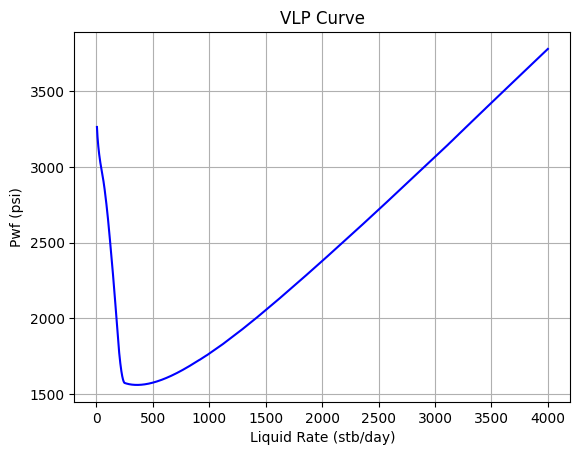

In [13]:
pvt_data = BlackOilPVT(sg_gas=0.65, sg_oil=141.5/(131.5+35), sg_water=1.07, watercut =0.33 )
Rsb = pvt_data.rsb_from_test(480, 346.6, 1800, 80)
fp = pvt_data.fluid_properties_dict(346.6, 80, Rsb, 1800)

bb = Beggs_Brill(2.441/12, 2.875/12, 5.5/12, 0.0006/12, pvt_data, fp)
bb.plot_vlp_curve(346.6, 80, 130, 8245, 5, 4000, 50)